<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW4/HW4_NLP_Transformer_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW4

In [10]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import requests

from torch import nn
from torch import functional as F
from torch import optim

!pip install torchinfo

import matplotlib.pyplot as plt


from torchinfo import summary



In [11]:
text_sequence = """“Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.”"""

In [12]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [13]:
# We need to convert this text into a list of sorted indices for
print(f"Total Input Characters: {len(text_sequence)}")
sorted_text = list(sorted(set(text_sequence)))
print(f"Total Unique Characters: {len(sorted_text)}")
print(sorted_text)

ix_to_char = {i: ch for i,ch in enumerate(sorted_text)}

char_to_ix = {ch: i for i, ch in enumerate(sorted_text)}

Total Input Characters: 2393
Total Unique Characters: 47
['\n', ' ', "'", '(', ')', ',', '-', '.', 'A', 'D', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '“', '”']


In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        self.encoding[:, 0::2] = torch.sin(position * div_term)
        self.encoding[:, 1::2] = torch.cos(position * div_term)
        self.encoding = self.encoding.unsqueeze(0).to(device)

    def forward(self, x):
        return x + self.encoding[:, :x.size(1)].detach()

#Create Model
class TransformerModel(nn.Module):
  def __init__(self, input_size, output_size, hidden_size, nhead, num_layers):
    super(TransformerModel, self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.pos_encoder = PositionalEncoding(hidden_size)
    encoder_layers = nn.TransformerEncoderLayer(hidden_size, nhead, batch_first=True)
    self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    embedded = self.pos_encoder(self.embedding(x))
    transformer_output = self.transformer_encoder(embedded)
    return self.fc(transformer_output[:, -1, :])

In [15]:
#Splitting into train and test datasets
from sklearn.model_selection import train_test_split
def preprocess_text(text, sequence_length):
    # Preparing the dataset
    max_length = sequence_length  # Maximum length of input sequences
    X = []
    y = []
    for i in range(len(text) - max_length):
        sequence = text[i:i + max_length]
        label = text[i + max_length]
        X.append([char_to_ix[char] for char in sequence])
        y.append(char_to_ix[label])

    X = np.array(X)
    y = np.array(y)

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.10, random_state=1
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=15/90, random_state=1
    )

    X_train = torch.tensor(X_train, dtype=torch.long).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val = torch.tensor(X_val, dtype=torch.long).to(device)
    y_val = torch.tensor(y_val, dtype=torch.long).to(device)
    X_test = torch.tensor(X_test, dtype=torch.long).to(device)
    y_test = torch.tensor(y_test, dtype=torch.long).to(device)

    batch_size = 256

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size, shuffle=False)


    return train_loader, val_loader, test_loader

In [16]:
def createPlot(sequence_length, train_loss_list, val_loss_list, val_accuracy_list):
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(train_loss_list, label='Train Loss')
  plt.plot(val_loss_list, label='Val Loss')
  plt.title(f'Loss Curves Sequence Length:{sequence_length}')
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(val_accuracy_list, label='Val Accuracy')
  plt.title(f'Validation Accuracy Sequence Length:{sequence_length}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.show()

In [17]:
#Hyperparameters
hidden_size = 64
num_layers = 2
nhead = 2
lr = 0.001
epochs = 100
input_size = len(sorted_text)

criterion = nn.CrossEntropyLoss()


Epoch 0, Loss: 3.2463, Val Accuracy: 0.1373, Val Loss: 3.1907
Training time for Epoch 0: 0.901981 seconds
Epoch 20, Loss: 2.1669, Val Accuracy: 0.3431, Val Loss: 2.3422
Training time for Epoch 20: 0.066429 seconds
Epoch 40, Loss: 1.6966, Val Accuracy: 0.2941, Val Loss: 2.4759
Training time for Epoch 40: 0.062678 seconds
Epoch 60, Loss: 1.2079, Val Accuracy: 0.4314, Val Loss: 2.3500
Training time for Epoch 60: 0.057546 seconds
Epoch 80, Loss: 0.6724, Val Accuracy: 0.3922, Val Loss: 2.9132
Training time for Epoch 80: 0.057011 seconds


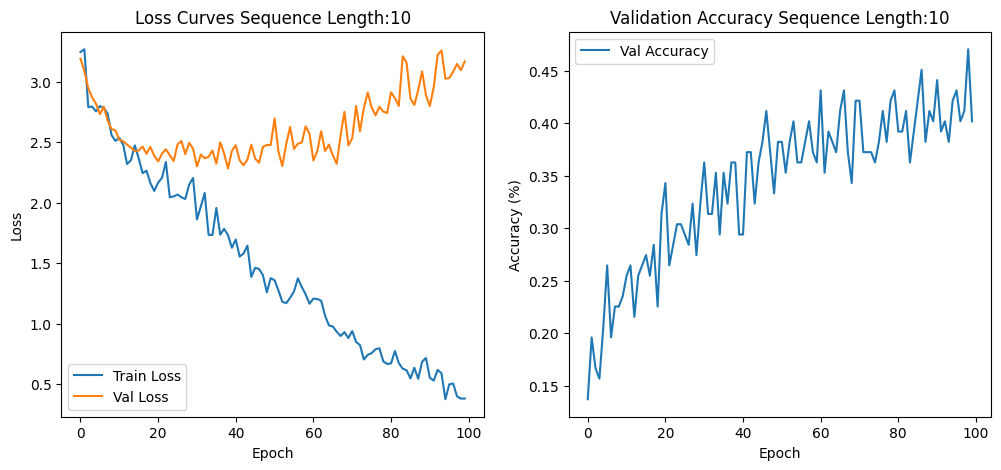

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 47]                   --
├─Embedding: 1-1                              [1, 47, 64]               3,008
├─PositionalEncoding: 1-2                     [1, 47, 64]               --
├─TransformerEncoder: 1-3                     [1, 47, 64]               --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 47, 64]               281,152
│    │    └─TransformerEncoderLayer: 3-2      [1, 47, 64]               281,152
├─Linear: 1-4                                 [1, 47]                   3,055
Total params: 568,367
Trainable params: 568,367
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.54
Input size (MB): 0.00
Forward/backward pass size (MB): 1.71
Params size (MB): 2.14
Estimated Total Size (MB): 3.85
running test set evaluation
Final Test Accuracy: 38.9121%
Epoch 0, Loss: 3.13

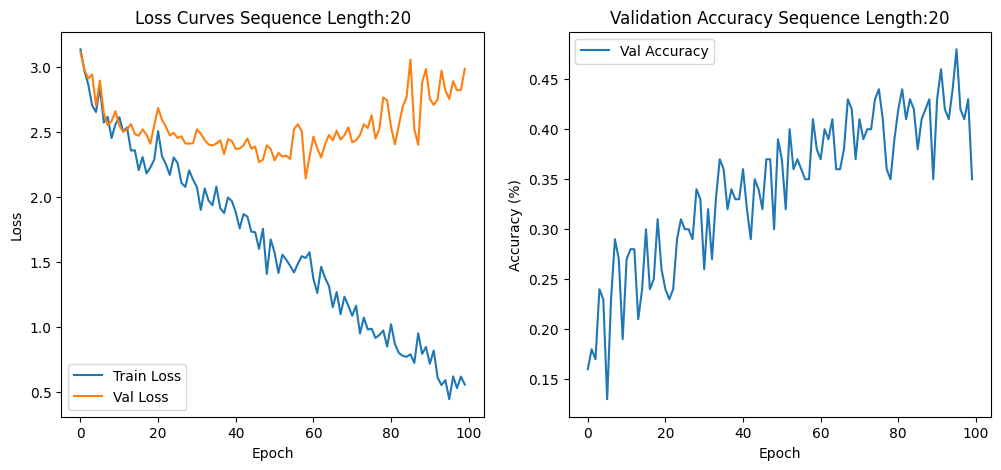

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 47]                   --
├─Embedding: 1-1                              [1, 47, 64]               3,008
├─PositionalEncoding: 1-2                     [1, 47, 64]               --
├─TransformerEncoder: 1-3                     [1, 47, 64]               --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 47, 64]               281,152
│    │    └─TransformerEncoderLayer: 3-2      [1, 47, 64]               281,152
├─Linear: 1-4                                 [1, 47]                   3,055
Total params: 568,367
Trainable params: 568,367
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.54
Input size (MB): 0.00
Forward/backward pass size (MB): 1.71
Params size (MB): 2.14
Estimated Total Size (MB): 3.85
running test set evaluation
Final Test Accuracy: 42.4370%
Epoch 0, Loss: 3.15

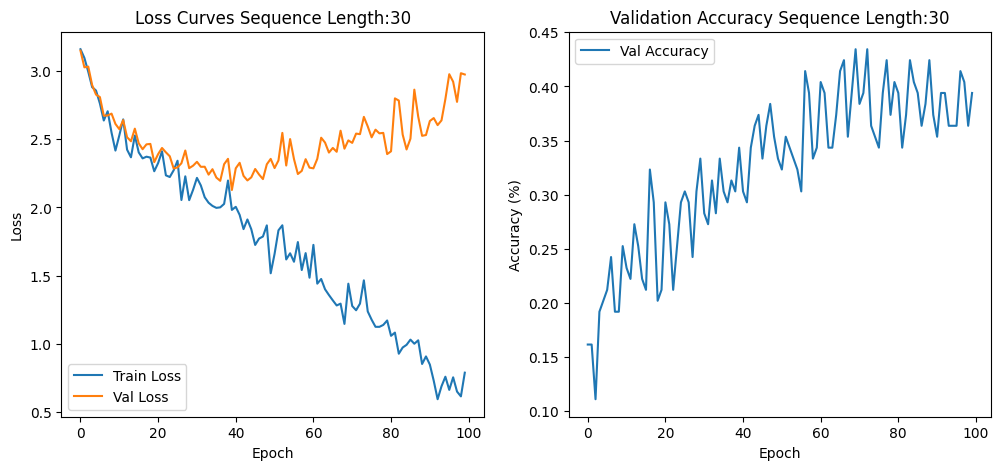

Layer (type:depth-idx)                        Output Shape              Param #
TransformerModel                              [1, 47]                   --
├─Embedding: 1-1                              [1, 47, 64]               3,008
├─PositionalEncoding: 1-2                     [1, 47, 64]               --
├─TransformerEncoder: 1-3                     [1, 47, 64]               --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 47, 64]               281,152
│    │    └─TransformerEncoderLayer: 3-2      [1, 47, 64]               281,152
├─Linear: 1-4                                 [1, 47]                   3,055
Total params: 568,367
Trainable params: 568,367
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.54
Input size (MB): 0.00
Forward/backward pass size (MB): 1.71
Params size (MB): 2.14
Estimated Total Size (MB): 3.85
running test set evaluation
Final Test Accuracy: 32.0675%


In [18]:
input_lengths = [10, 20, 30]
for seq_len in input_lengths:
  model = TransformerModel(len(sorted_text), len(sorted_text), hidden_size, nhead, num_layers).to(device)
  optimizer = optim.Adam(model.parameters(), lr = lr)
  train_loader, val_loader, test_loader = preprocess_text(text_sequence, seq_len)

  ###This is where training begins
  #Lists for storing loss and validation values
  train_loss_list = []
  val_loss_list = []
  val_accuracy_list = []


  #Create a new training loop for each input_length
  for epoch in range(epochs):
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()
    model.train()

    optimizer.zero_grad()
    for X_train, y_train in train_loader:
      y_pred = model(X_train)  # Forward pass
      loss = criterion(y_pred, y_train)  # Compute loss
      loss.backward()  # Backward pass
      optimizer.step()  # Update model parameters

    end_event.record()

    torch.cuda.synchronize()

    # Calculate time in milliseconds
    elapsed_time_ms = start_event.elapsed_time(end_event)



    for X_val, y_val in val_loader:
      #Here is where we evaluate the model on the current epoch
      model.eval()
      with torch.no_grad():
        val_output = model(X_val) # Take test dataset and run it through this epoch's model

        val_loss = criterion(val_output, y_val) #Find the loss

        _, predicted = torch.max(val_output, 1) #Here we find what the output was (what letter)

        val_accuracy = (predicted == y_val).float().mean()#Here we take each answer from our model,
                                                          #compare it to the ground truth, and find how accurate we are

    train_loss_list.append(loss.item()) #Take this epoch's training loss and add it
                                        #to the training loss list (of all epochs)
    val_loss_list.append(val_loss.item())
    val_accuracy_list.append(val_accuracy.item())

    if (epoch % 20 == 0):
      print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy.item():.4f}, Val Loss: {val_loss.item():.4f}')
      print(f"Training time for Epoch {epoch}: {elapsed_time_ms / 1000:.6f} seconds")
  createPlot(seq_len, train_loss_list, val_loss_list, val_accuracy_list)
  print(summary(model, input_size = (1,input_size), dtypes=[torch.long]))

  print("running test set evaluation")
  model.eval()
  for X_test, y_test in test_loader:
    with torch.no_grad():
      test_output = model(X_test)
      test_loss = criterion(test_output, y_test)
      _, predicted = torch.max(test_output, 1)
      test_accuracy = (predicted == y_test).float().mean()
      print(f"Final Test Accuracy: {100 * test_accuracy:.4f}%")



In [19]:
def predictNextChar(model, char_to_ix, ix_to_char, initial_str):
  model.eval()
  max_length = 10
  with torch.no_grad():
    initial_input = torch.tensor([char_to_ix[c] for c in initial_str], dtype=torch.long).unsqueeze(0).to(device)
    prediction = model(initial_input)
    predicted_index = torch.argmax(prediction, dim=1).item()
    return ix_to_char[predicted_index]

In [22]:
test_str = "hello worl"
for i in range(30):
  predicted_char = predictNextChar(model, char_to_ix, ix_to_char, test_str)
  test_str += predicted_char
print(f"Predicted next character: '{test_str}'")

Predicted next character: 'hello worlyzext-chext-bas predicecedicec'
